In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten

In [2]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (25000,)
Testing Data Shape: (25000,)


In [4]:
max_length = 200

X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

print("Padded Training Shape:", X_train.shape)
print("Padded Testing Shape:", X_test.shape)

Padded Training Shape: (25000, 200)
Padded Testing Shape: (25000, 200)


In [5]:
model = Sequential()

In [6]:
model.add(Embedding(input_dim=vocab_size, output_dim=32, input_length=max_length))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [7]:
model.add(Flatten())

In [8]:
model.add(Dense(64, activation='relu'))

In [9]:
model.add(Dense(1, activation='sigmoid'))

In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
# Step 7: Build Model Properly

model.build(input_shape=(None, 200))

# Display Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       409,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,189,189 (8.35 MB)

 Trainable params: 729,729 (2.78 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,459,460 (5.57 MB)

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.7400 - loss: 0.4913 - val_accuracy: 0.8548 - val_loss: 0.3408
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9227 - loss: 0.2039 - val_accuracy: 0.8434 - val_loss: 0.3779
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9840 - loss: 0.0636 - val_accuracy: 0.8594 - val_loss: 0.3768
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9974 - loss: 0.0155 - val_accuracy: 0.8606 - val_loss: 0.4160
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.9995 - loss: 0.0049 - val_accuracy: 0.8616 - val_loss: 0.4550


In [13]:
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8572 - loss: 0.4559

Test Loss: 0.45586860179901123
Test Accuracy: 0.857200026512146


In [14]:
predictions = model.predict(X_test[:5])

print("\nPredictions:")
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step

Predictions:
[[0.0102431 ]
 [0.9999277 ]
 [0.92425096]
 [0.1195024 ]
 [0.99961144]]


In [15]:
predicted_classes = (predictions > 0.5).astype("int32")

print("\nPredicted Classes:")
print(predicted_classes)

print("\nActual Classes:")
print(y_test[:5])


Predicted Classes:
[[0]
 [1]
 [1]
 [0]
 [1]]

Actual Classes:
[0 1 1 0 1]


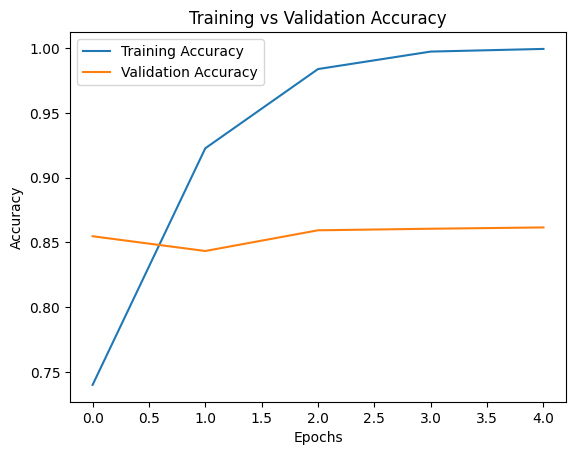

In [16]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()